# DSA4262 Individual Assignment 2: Stress Detection in Reddit Posts
## Name: Fong Kang Wei

This project develops interpretable machine learning models to detect stress signals in Reddit posts from the Dreaddit dataset, with a focus on both predictive performance and understanding the linguistic and psychological patterns underlying stress expression.

The workflow follows these key stages:
- Conduct exploratory data analysis to examine dataset structure, label balance, subreddit composition, text length, sentiment, and selected psychological lexical features.
- Build a text-only baseline model using TF-IDF and Logistic Regression, tuned via grid search with stratified cross-validation.
- Perform model sense-making analyses, including top predictive words, per-subreddit performance, qualitative error analysis, and the role of annotator confidence.
- Extend to a combined model by integrating engineered psychological and behavioural features (e.g. LIWC, sentiment, readability, social metrics) with TF-IDF text features to test incremental predictive value.
- Analyse feature importance for interpretability and compare precision–recall trade-offs between models.
- Conclude with ethical considerations regarding false positives, false negatives, and responsible deployment in mental health contexts.

GitHub Repository: https://github.com/kangwei01/dsa4262-predicting-stress-from-social-media-text#

# 1 Load Dreaddit Train Data and Test Data

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

DATA_DIR = Path('data')
train_path = DATA_DIR / 'dreaddit-train.csv'
test_path = DATA_DIR / 'dreaddit-test.csv'
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

## 1.1 Data Quality Checks

In [2]:
# Check for missing values
train_missing_rows = train_df.isnull().any(axis=1).sum()
test_missing_rows = test_df.isnull().any(axis=1).sum()

print(f"Train rows with any missing value: {train_missing_rows}")
print(f"Test rows with any missing value: {test_missing_rows}")

# Check for duplicate rows
print("\nDuplicate rows:")
print("Train duplicates:", train_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train rows with any missing value: 0
Test rows with any missing value: 0

Duplicate rows:
Train duplicates: 0
Test duplicates: 0


# 2 Exploratory Data Analysis (EDA)

## 2.1 Preview the Dreaddit Dataset

In [3]:
print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

Train shape: (2838, 116)
Test shape: (715, 116)


In [4]:
# Preview and categorise columns

print(train_df.columns)

from collections import defaultdict

groups = defaultdict(list)

for col in train_df.columns:
    prefix = col.split('_')[0]
    groups[prefix].append(col)

for k, v in groups.items():
    print(f"{k}: {len(v)} columns")

Index(['subreddit', 'post_id', 'sentence_range', 'text', 'id', 'label',
       'confidence', 'social_timestamp', 'social_karma', 'syntax_ari',
       ...
       'lex_dal_min_pleasantness', 'lex_dal_min_activation',
       'lex_dal_min_imagery', 'lex_dal_avg_activation', 'lex_dal_avg_imagery',
       'lex_dal_avg_pleasantness', 'social_upvote_ratio',
       'social_num_comments', 'syntax_fk_grade', 'sentiment'],
      dtype='object', length=116)
subreddit: 1 columns
post: 1 columns
sentence: 1 columns
text: 1 columns
id: 1 columns
label: 1 columns
confidence: 1 columns
social: 4 columns
syntax: 2 columns
lex: 102 columns
sentiment: 1 columns


We begin the EDA by examining the full list of columns and group them by their prefixes (e.g. lex_, social_, `syntax_`). This categorisation provides a high-level understanding of the different feature types available in the dataset:

- Textual content: the raw post text (`text`)
- Labels and metadata: stress label, annotator confidence, subreddit, timestamps
- Lexical psychological features: LIWC and DAL-based indicators capturing emotional tone, cognition, and affect
- Social engagement metrics: upvote ratio and number of comments
- Readability and syntactic measures: features such as ARI and Flesch-Kincaid grade
- Sentiment score: overall polarity of the text

This grouping is important for methodological planning. It highlights that the dataset contains both raw linguistic signals (text) and engineered psychological or behavioural features. This distinction directly informs the modelling strategy: we first build a text-only baseline model to capture purely linguistic stress signals, and later extend it with engineered features to evaluate whether they provide predictive value beyond language alone.

## 2.2 Label Distribution

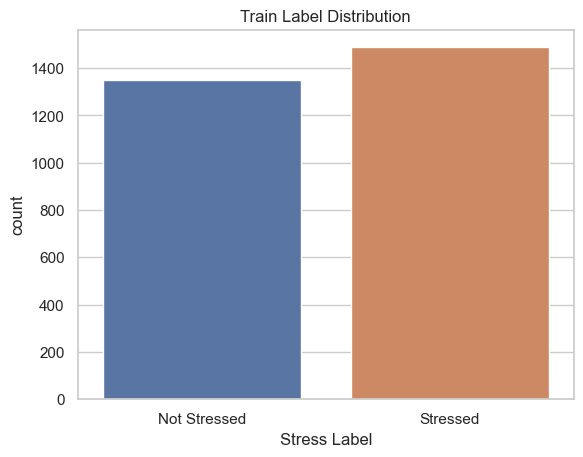

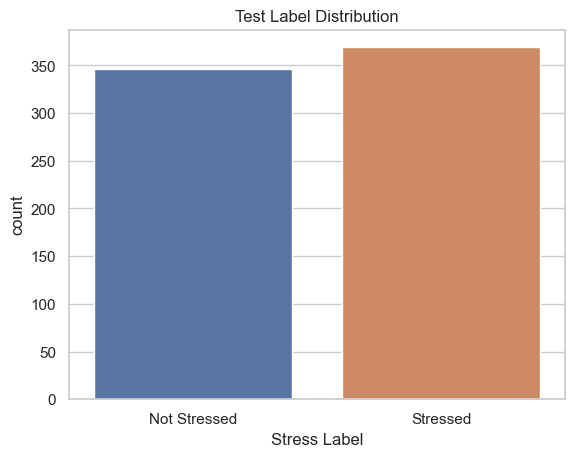

In [5]:
label_names = ['Not Stressed', 'Stressed']

# Plot train distribution
ax = sns.countplot(x='label', data=train_df)
ax.set_xticklabels(label_names)
plt.title("Train Label Distribution")
plt.xlabel("Stress Label")
plt.show()

# Plot test distribution
ax = sns.countplot(x='label', data=test_df)
ax.set_xticklabels(label_names)
plt.title("Test Label Distribution")
plt.xlabel("Stress Label")
plt.show()

We examine the distribution of stress labels in the training and test sets. Both splits are relatively balanced, with slightly more “Stressed” than “Not Stressed” instances, and the proportions are consistent across the two sets. This indicates that the predefined split preserves the underlying class distribution.

A balanced label distribution reduces the risk of the model defaulting to majority-class predictions and ensures that evaluation metrics such as F1-score remain informative. It also supports the use of cross-validation later, as similar class proportions across folds lead to more stable and reliable performance estimates.

## 2.3 Post Distribution by Subreddit

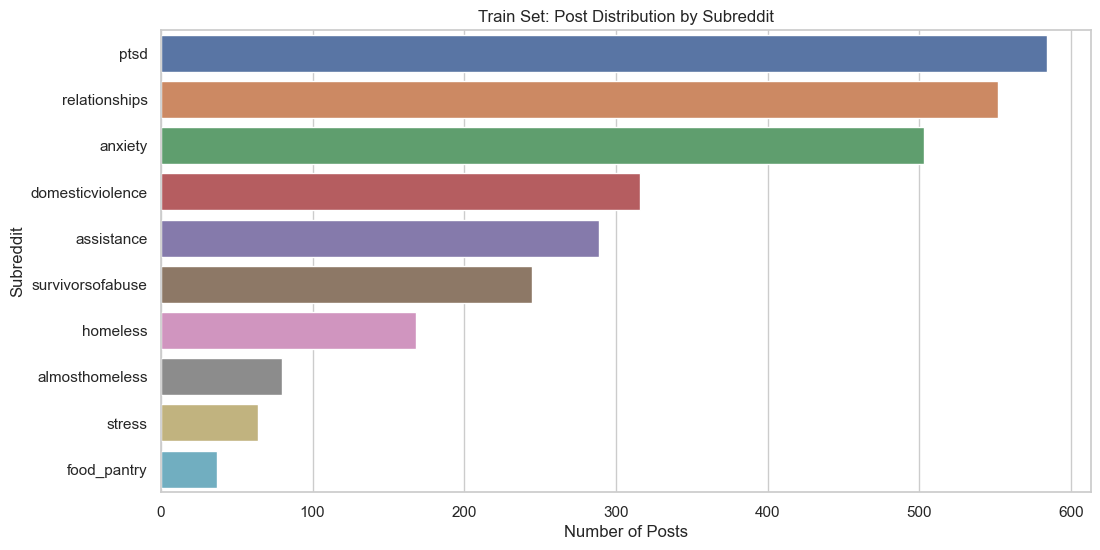

In [6]:
# Plot number of posts by subreddit for train set

plt.figure(figsize=(12,6))
sns.countplot(
    y='subreddit',
    data=train_df,
    order=train_df['subreddit'].value_counts().index
)
plt.title("Train Set: Post Distribution by Subreddit")
plt.xlabel("Number of Posts")
plt.ylabel("Subreddit")
plt.show()

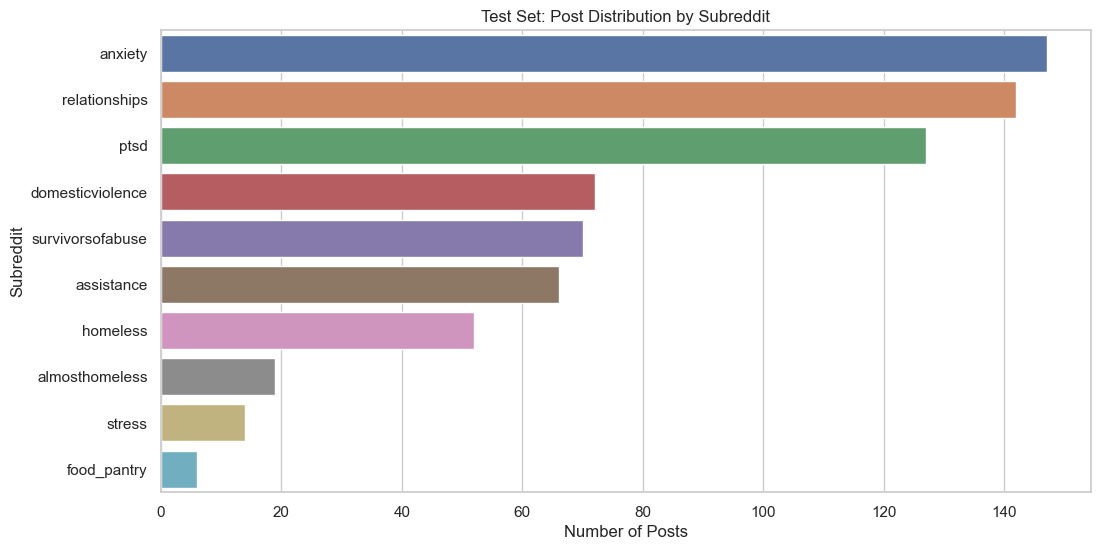

In [7]:
# Plot number of posts by subreddit for test set

plt.figure(figsize=(12,6))
sns.countplot(
    y='subreddit',
    data=test_df,
    order=test_df['subreddit'].value_counts().index
)
plt.title("Test Set: Post Distribution by Subreddit")
plt.xlabel("Number of Posts")
plt.ylabel("Subreddit")
plt.show()

In [8]:
# Proportion of total posts contributed by each subreddit

subreddit_dist = (
    train_df['subreddit']
    .value_counts(normalize=True)
    .rename("proportion")
    .to_frame()
)

subreddit_dist

,proportion
subreddit,
ptsd,0.205779
relationships,0.194503
anxiety,0.177237
domesticviolence,0.111346
assistance,0.101832
survivorsofabuse,0.086328
homeless,0.059197
almosthomeless,0.028189
stress,0.022551


We next examine how posts are distributed across different subreddits in both the training and test sets. The distributions are broadly similar across splits, with subreddits such as ptsd, relationships, and anxiety contributing the largest number of posts, while others like food_pantry and stress are relatively underrepresented.

This imbalance across communities is important because it implies that the model will be exposed more frequently to certain thematic contexts of stress (e.g. trauma, interpersonal issues, anxiety) than others. As a result, the model may learn stronger linguistic patterns for high-volume subreddits, while performance on low-volume subreddits may be less stable due to limited training examples.

Understanding this distribution also motivates later per-subreddit performance analysis, where we investigate whether the model performs better on communities with clearer or more explicit expressions of distress compared to those with fewer or more nuanced posts.

## 2.4 Text Length Distribution by Stress Label

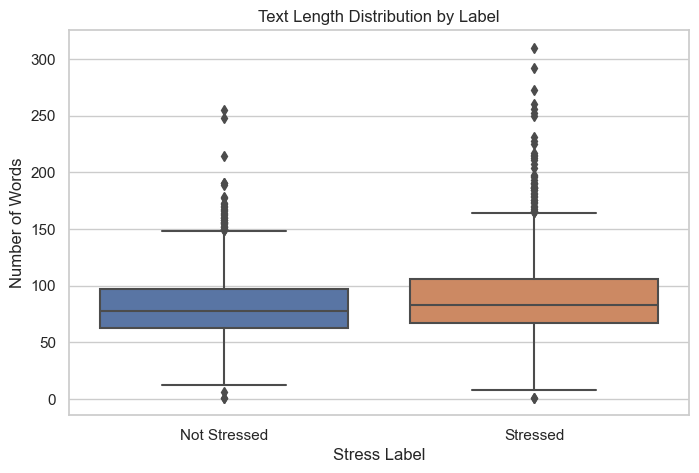

Text Length Statistics by Label:


,mean,median,std,count
Not Stressed,82.168148,78.0,29.135389,1350
Stressed,88.846774,83.0,34.614848,1488



Stressed posts are 8.13% longer on average.


In [9]:
train_df['text_length'] = train_df['text'].str.split().apply(len)

plt.figure(figsize=(8,5))
sns.boxplot(x='label', y='text_length', data=train_df)
plt.xticks([0,1], ['Not Stressed', 'Stressed'])
plt.title("Text Length Distribution by Label")
plt.xlabel("Stress Label")
plt.ylabel("Number of Words")
plt.show()

train_df.groupby('label')['text_length'].describe()

# Summary statistics by label
length_stats_label = train_df.groupby('label')['text_length'].agg(['mean','median','std','count'])
length_stats_label.index = ['Not Stressed', 'Stressed']

print("Text Length Statistics by Label:")
display(length_stats_label)

# Percentage difference (Stressed vs Not Stressed)
mean_ns = length_stats_label.loc['Not Stressed', 'mean']
mean_s = length_stats_label.loc['Stressed', 'mean']

perc_diff = ((mean_s - mean_ns) / mean_ns) * 100
print(f"\nStressed posts are {perc_diff:.2f}% longer on average.")

We examine whether stressed and non-stressed posts differ in textual length, measured by the number of words per post. The boxplot and summary statistics show that stressed posts are slightly longer on average, with an approximately 8.13% increase in mean length compared to non-stressed posts.

This suggests that individuals experiencing stress tend to provide more detailed and narrative descriptions of their situations, potentially expressing emotions and contextual information more extensively. Longer posts offer richer lexical cues, which may make stress signals more detectable by text-based models. In contrast, shorter posts may contain fewer observable indicators of distress, increasing the difficulty of accurate classification.

## 2.5 Text Length Distribution by Subreddit

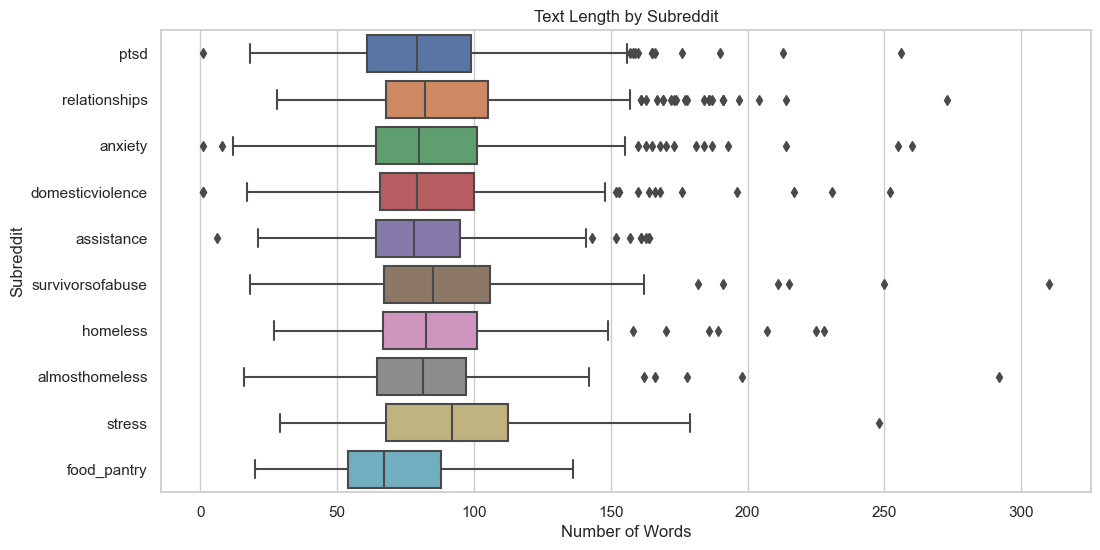

Text Length Statistics by Subreddit:


,mean,median,std,count
subreddit,,,,
stress,94.593750,92.0,36.464255,64
survivorsofabuse,90.020408,85.0,36.160214,245
relationships,89.592391,82.0,32.727087,552
almosthomeless,86.750000,81.5,39.582153,80
homeless,86.636905,82.5,33.659163,168
anxiety,85.312127,80.0,32.104101,503
domesticviolence,85.167722,79.0,32.233085,316
ptsd,82.148973,79.0,29.837986,584
assistance,81.525952,78.0,27.633015,289


In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(
    y='subreddit',
    x='text_length',
    data=train_df,
    order=train_df['subreddit'].value_counts().index
)
plt.title("Text Length by Subreddit")
plt.xlabel("Number of Words")
plt.ylabel("Subreddit")
plt.show()

# Summary statistics by subreddit
length_stats_subreddit = train_df.groupby('subreddit')['text_length'].agg(['mean','median','std','count'])

# Sort by descending mean length
length_stats_subreddit = length_stats_subreddit.sort_values(by='mean', ascending=False)

print("Text Length Statistics by Subreddit:")
display(length_stats_subreddit)


We analyse how post length varies across different subreddits to understand whether certain communities encourage more detailed or narrative-style expressions. The boxplot and summary statistics show noticeable variation in average text length across subreddits, with communities such as stress, survivorsofabuse, and relationships exhibiting longer posts on average, while subreddits like food_pantry and assistance tend to have shorter posts.

This variation suggests that community context influences how individuals express their experiences. Subreddits focused on trauma, interpersonal issues, or ongoing struggles appear to encourage more elaborate narratives, whereas resource-oriented communities often contain shorter, more direct requests for help. 

These differences are important for model interpretation, as longer posts provide richer linguistic cues that may improve stress detectability, while shorter posts may contain fewer explicit indicators and therefore be more challenging for the classifier.

## 2.6 Sentiment Distribution by Label

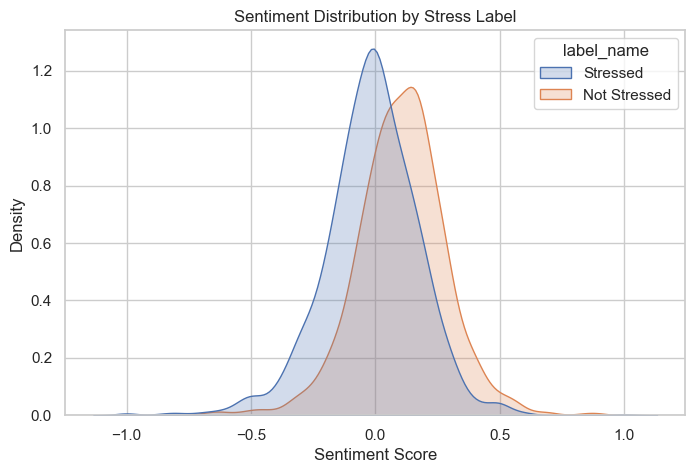

In [11]:
label_map = {0: "Not Stressed", 1: "Stressed"}
train_df["label_name"] = train_df["label"].map(label_map)

plt.figure(figsize=(8,5))
sns.kdeplot(data=train_df, x="sentiment", hue="label_name", fill=True)
plt.title("Sentiment Distribution by Stress Label")
plt.xlabel("Sentiment Score")
plt.ylabel("Density")
plt.show()

We examine how sentiment scores differ between stressed and non-stressed posts to understand whether emotional polarity aligns with stress labels. The density plot shows that stressed posts tend to have slightly more negative sentiment on average, while non-stressed posts are more centred around neutral to mildly positive values. 

However, the substantial overlap between the two distributions indicates that sentiment alone is not sufficient to distinguish stressed from non-stressed posts. Individuals may express distress using neutral or even positive language (e.g. reflective or hopeful tones), while some non-stressed posts may still contain negative sentiment when discussing challenges or past events.

This suggests that while sentiment is a useful auxiliary signal, stress detection requires richer linguistic and contextual features beyond simple polarity.

## 2.7 Distribution of LIWC Lexical Features by Label

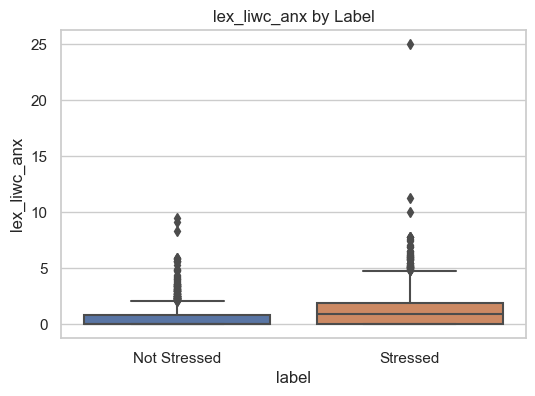

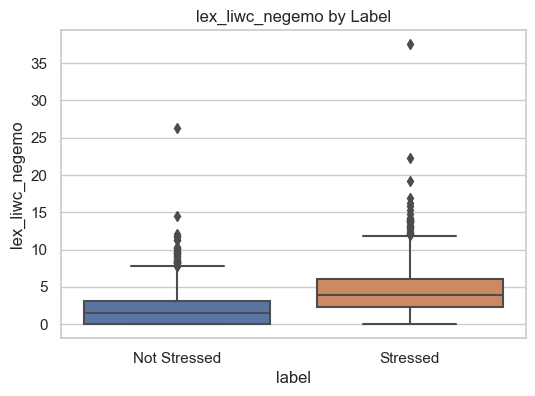

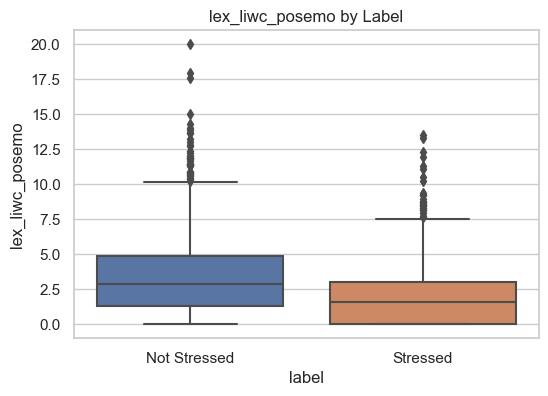

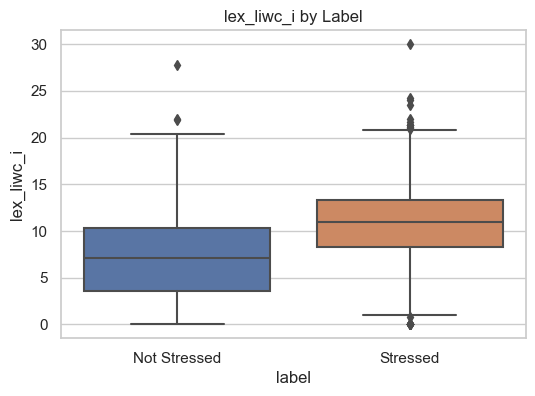

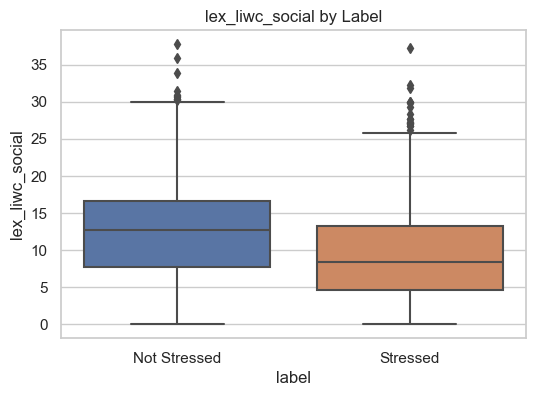

In [12]:
selected_features = [
    'lex_liwc_anx', 'lex_liwc_negemo', 'lex_liwc_posemo',
    'lex_liwc_i', 'lex_liwc_social'
]

for feat in selected_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='label', y=feat, data=train_df)
    plt.xticks([0,1], ['Not Stressed', 'Stressed'])
    plt.title(f"{feat} by Label")
    plt.show()


We examine selected LIWC-based lexical features to assess whether psychologically meaningful linguistic patterns differ between stressed and non-stressed posts. The features analysed include anxiety-related words (`lex_liwc_anx`), negative emotion words (`lex_liwc_negemo`), positive emotion words (`lex_liwc_posemo`), first-person pronouns (`lex_liwc_i`), and social-related terms (`lex_liwc_social`).

The boxplots show that stressed posts generally exhibit higher levels of anxiety-related and negative emotion words, as well as greater use of first-person pronouns, indicating more self-focused and affect-laden language. In contrast, non-stressed posts tend to contain slightly higher levels of positive emotion and social-related terms on average, suggesting more neutral or externally oriented discourse. These patterns align with psychological theories of stress expression, where distressed individuals are more likely to use self-referential and negative emotional language.

## 2.8 Distribution of Annotation Confidence Scores

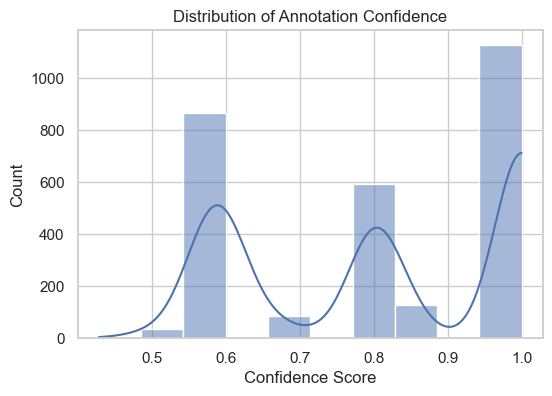

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1350.0,0.804543,0.179652,0.571429,0.6,0.8,1.0,1.0
1,1488.0,0.812990,0.174597,0.428571,0.6,0.8,1.0,1.0


In [13]:
# Visualise overall distribution of annotator confidence
plt.figure(figsize=(6,4))
sns.histplot(train_df['confidence'], bins=10, kde=True)
plt.title("Distribution of Annotation Confidence")
plt.xlabel("Confidence Score")
plt.show()

# Compare confidence levels between stressed and non-stressed posts
train_df.groupby('label')['confidence'].describe()

We analyse the distribution of annotator confidence scores to assess the reliability of the ground-truth labels. The histogram with KDE shows that most confidence scores are relatively high, with a large concentration around 0.8 to 1.0 for both stressed and non-stressed posts.

The summary statistics by label show similar mean confidence levels for both classes, suggesting that neither stressed nor non-stressed posts are systematically more ambiguous. However, the presence of some lower-confidence annotations, especially around 0.6, cannot be ignored and implies that certain posts are inherently difficult to label, likely due to indirect, nuanced, or context-dependent expressions of stress.

This insight is important for later error analysis, as some model misclassifications may stem not only from model limitations but also from ambiguity in the data itself. Considering annotation confidence therefore provides additional context when interpreting prediction errors and evaluating model performance.

# 3 Light Data Cleaning

In [14]:
def clean(text):
    text = str(text).lower()
    # remove URLs
    text = re.sub(r'http\S+', '', text) 
    # normalize spaces
    text = re.sub(r'\s+', ' ', text)      
    return text.strip()

train_df['clean_text'] = train_df['text'].apply(clean)
test_df['clean_text'] = test_df['text'].apply(clean)


We perform minimal text preprocessing by converting all text to lowercase, removing URLs, and normalising whitespace. This light cleaning standardises the textual input while preserving the original semantic content of each post.

The goal is to reduce noise that could negatively affect TF-IDF feature extraction (e.g. inconsistent casing or irrelevant URL tokens) without removing meaningful linguistic signals such as punctuation or stopwords, which may carry psychological or emotional cues. Maintaining these signals is important for stress detection, as subtle variations in wording and expression can be informative.

This approach ensures a balance between improving data consistency and retaining the nuanced language needed for accurate modelling and interpretation.

# 4 TF-IDF + Logistic Regression Baseline

## 4.1 Grid Search to Find Best Hyperparameters

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

X_train = train_df["clean_text"]
y_train = train_df["label"]

# Pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=3000, random_state=42))
])

# Parameter grid for grid search
param_grid = {
    # TF-IDF parameters
    "tfidf__ngram_range": [(1,1), (1,2)],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.9, 0.95, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__stop_words": [None, "english"],

    # Logistic Regression parameters
    "clf__C": [0.1, 0.3, 1, 3, 10],
    "clf__class_weight": [None, "balanced"],
    "clf__solver": ["liblinear"],   # stable for sparse text
    "clf__penalty": ["l2"]
}

# Stratified CV ensures class balance per fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__C': [0.1, 0.3, ...], 'clf__class_weight': [None, 'balanced'], 'clf__penalty': ['l2'], 'clf__solver': ['liblinear'], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [16]:
print("Best CV F1 Score:", grid_search.best_score_)
print("\nBest Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"{k}: {v}")

Best CV F1 Score: 0.7915102053241709

Best Parameters:
clf__C: 3
clf__class_weight: balanced
clf__penalty: l2
clf__solver: liblinear
tfidf__max_df: 0.95
tfidf__min_df: 1
tfidf__ngram_range: (1, 2)
tfidf__stop_words: None
tfidf__sublinear_tf: True


We first build a text-only baseline model using TF-IDF with Logistic Regression, and we use grid search with cross-validation to find the best model configuration (hyperparameter tuning). This lets us detect stress signals purely from language, while making the tuning process systematic and reproducible.

TF-IDF is chosen because stress in Reddit posts is often expressed through clear words and phrases such as “overwhelmed”, “can’t cope”, or self-focused language. TF-IDF highlights which words and n-grams are most useful for separating stressed from non-stressed posts. It is also interpretable as the model’s weights can be traced back to specific words, which supports sense-making and transparency in a mental health setting.

Logistic Regression is selected over deep learning models like BERT mainly for explainability. Deep models can perform well, but they are harder to interpret and it is less clear why a post was flagged. In contrast, logistic regression provides straightforward coefficients that show which words push predictions toward stress or non-stress. Given the goal of understanding model behaviour, a linear model offers a strong balance between performance, stability, and interpretability.

Finally, grid search tunes key TF-IDF and classifier settings (e.g. n-gram range, document frequency thresholds, class weighting, regularisation strength). Stratified cross-validation keeps class proportions similar in each fold, giving more stable F1 estimates and reducing the chance that results depend on one lucky split.

## 4.2 Baseline Model Results on Held-out Test Set

In [17]:
from sklearn.metrics import classification_report, f1_score

X_test = test_df["clean_text"]
y_test = test_df["label"]

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Test F1 Score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Test F1 Score: 0.7558859975216853

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.62      0.68       346
           1       0.70      0.83      0.76       369

    accuracy                           0.72       715
   macro avg       0.73      0.72      0.72       715
weighted avg       0.73      0.72      0.72       715



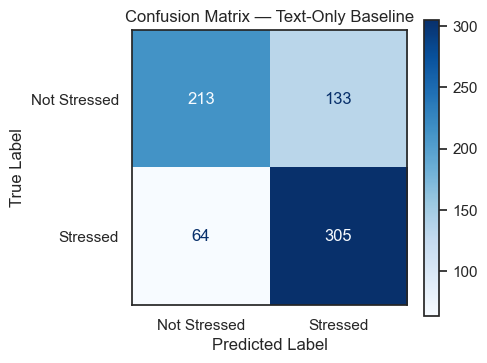

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Stressed", "Stressed"]
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)

    ax.set_title("Confusion Matrix — Text-Only Baseline")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    plt.tight_layout()
    plt.show()

In [19]:
# Save the predictions

test_df["pred_label"] = y_pred
test_df["pred_prob"] = best_model.predict_proba(X_test)[:,1]

We evaluate the best TF-IDF + Logistic Regression model on the held-out test set to obtain an unbiased estimate of generalisation performance. This ensures that model tuning decisions made during cross-validation do not inflate evaluation metrics.

The model achieves an F1-score of approximately 0.76, with higher recall for stressed posts than for non-stressed posts. This indicates that the classifier is more sensitive to detecting stress-related language, which is desirable in mental health contexts where missing genuinely distressed individuals can have serious consequences.

The confusion matrix provides a clearer breakdown of prediction behaviour. The model correctly identifies a large proportion of stressed posts (true positives) while maintaining a reasonable number of true negatives. However, there are still notable false positives and false negatives, suggesting that some posts contain ambiguous or context-dependent expressions that are difficult to classify using lexical features alone.

Overall, the results confirm that linguistic cues captured through TF-IDF are effective for stress detection, while also highlighting the limitations of purely text-based representations in handling nuanced or implicit expressions of distress.

# 5 Baseline Model Interpretation and Analyses

## 5.1 Top Predictive Words

In [20]:
import numpy as np
import pandas as pd

# Extract trained components from pipeline
tfidf = best_model.named_steps["tfidf"]
clf = best_model.named_steps["clf"]

feature_names = tfidf.get_feature_names_out()
coefs = clf.coef_[0]

# Limit to top 20
top_n = 20

# Top predictors for stressed class (label = 1)
top_stress_idx = np.argsort(coefs)[-top_n:][::-1]
top_stress_words = pd.DataFrame({
    "word": feature_names[top_stress_idx],
    "coefficient": coefs[top_stress_idx]
})

# Top predictors for non-stressed class (label = 0)
top_nonstress_idx = np.argsort(coefs)[:top_n]
top_nonstress_words = pd.DataFrame({
    "word": feature_names[top_nonstress_idx],
    "coefficient": coefs[top_nonstress_idx]
})

print("Top Predictive Words for STRESSED posts:")
display(top_stress_words)

print("\nTop Predictive Words for NOT STRESSED posts:")
display(top_nonstress_words)

Top Predictive Words for STRESSED posts:


,word,coefficient
0,me,5.054329
1,my,4.493520
2,feel,3.556684
3,even,3.084015
4,am,3.021616
5,because,2.999743
6,just,2.991724
7,anxiety,2.828482
8,don,2.680669
9,what to,2.561936



Top Predictive Words for NOT STRESSED posts:


,word,coefficient
0,you,-3.553863
1,we,-2.793920
2,her,-2.432070
3,your,-2.420716
4,url,-2.300016
5,met,-2.199230
6,she,-2.064532
7,more,-1.906021
8,would,-1.749057
9,years,-1.663210


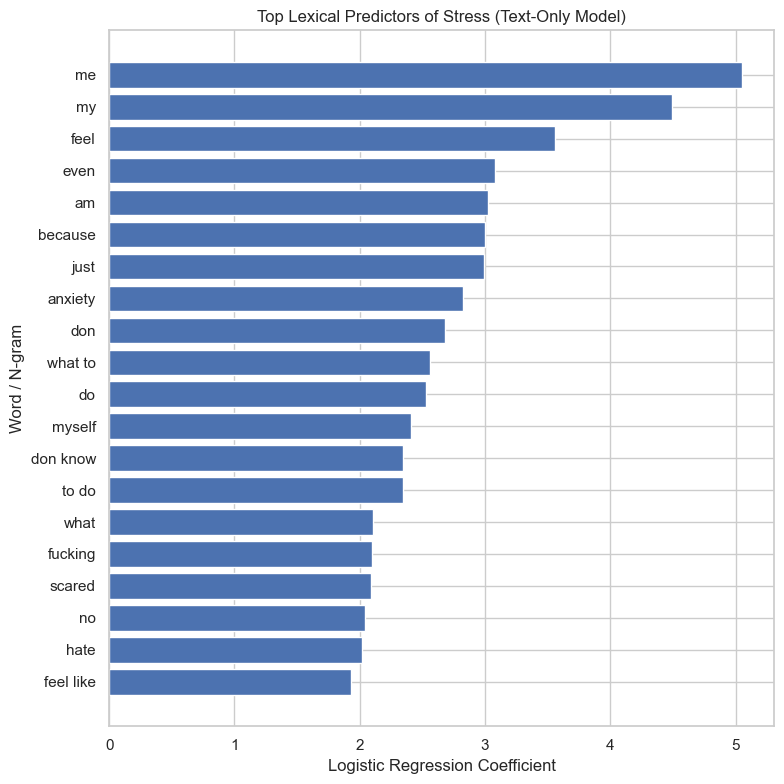

In [21]:
# Plot strongest lexical predictors of stress based on model coefficients
plot_df = top_stress_words.sort_values("coefficient")

plt.figure(figsize=(8, 8))
plt.barh(plot_df["word"], plot_df["coefficient"])
plt.title("Top Lexical Predictors of Stress (Text-Only Model)")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Word / N-gram")
plt.tight_layout()
plt.show()

To interpret the text-only model, we examine the highest-magnitude logistic regression coefficients associated with TF-IDF features. Positive coefficients correspond to words that increase the likelihood of a post being classified as stressed, while negative coefficients indicate words associated with non-stressed posts.

The top predictive words for stressed posts include self-referential and affect-laden terms such as “me”, “my”, “feel”, “anxiety”, and “scared”, reflecting introspective and emotionally expressive language.

In contrast, the top predictors for non-stressed posts include more socially oriented and conversational terms such as “you”, “we”, “thank”, and “met”, which suggest external focus and positive outlook rather than internal distress. These lexical patterns reinforce the idea that stress-related discourse tends to be more self-focused and emotionally charged.

Overall, this analysis provides primary interpretability for the baseline model by directly linking predictions to concrete linguistic markers. It confirms that the classifier relies on psychologically meaningful lexical cues rather than arbitrary patterns.

## 5.2 Per-Subreddit F1 Analysis

### 5.2.1 F1 Score by Subreddit

In [22]:
# Compute F1-score separately for each subreddit to compare model performance across communities
subreddit_f1 = (
    test_df.groupby("subreddit")
    .apply(lambda df: f1_score(df["label"], df["pred_label"]))
    .sort_values(ascending=False)
)

print("F1-score by subreddit:")
display(subreddit_f1)

F1-score by subreddit:


subreddit
domesticviolence    0.860215
food_pantry         0.857143
anxiety             0.828283
ptsd                0.807018
almosthomeless      0.769231
assistance          0.714286
survivorsofabuse    0.657534
relationships       0.637037
stress              0.631579
homeless            0.604651
dtype: float64

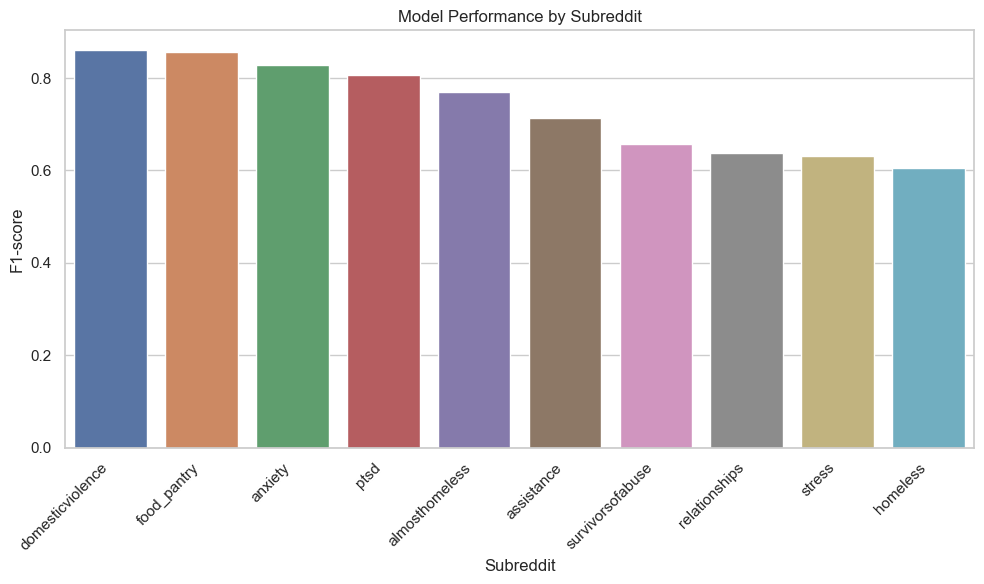

In [23]:
subreddit_counts = test_df["subreddit"].value_counts()

subreddit_perf = pd.DataFrame({
    "F1": subreddit_f1,
    "num_posts": subreddit_counts
}).sort_values("F1", ascending=False)

# Visualise model F1-score across subreddits to compare performance differences by community
plt.figure(figsize=(10,6))
sns.barplot(
    x=subreddit_perf.index,
    y=subreddit_perf["F1"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.xlabel("Subreddit")
plt.title("Model Performance by Subreddit")
plt.tight_layout()
plt.show()

We evaluate model performance separately across subreddits to assess whether stress detection varies by community context. The F1-score is computed for each subreddit using the held-out test predictions, and visualised to highlight differences in classification effectiveness across thematic communities.

The results show that the model performs better on subreddits such as domesticviolence, food_pantry, anxiety, and ptsd, while performance is lower on communities like relationships, stress, and homeless. This suggests that posts in mental-health-focused subreddits tend to contain clearer and more explicit expressions of distress, making them easier for the classifier to detect.

In contrast, posts from more general or socially nuanced communities may express stress more indirectly, through mixed emotional tones or contextual narratives, which are harder for lexical models to capture. This aligns with earlier EDA findings that community context and linguistic style vary across subreddits, influencing the strength and clarity of stress-related signals.

Overall, this analysis highlights that model performance is not uniform across domains, and that contextual differences in how stress is discussed play an important role in detectability.

### 5.2.2 F1 Score vs Stress Prevalence by Subreddit

In [24]:
# Add number of posts and stress prevelance in each subreddit for context

subreddit_label_rate = (
    test_df.groupby("subreddit")["label"]
    .mean()
    .rename("stress_rate")
)

subreddit_analysis = subreddit_perf.join(subreddit_label_rate)
display(subreddit_analysis)

,F1,num_posts,stress_rate
subreddit,,,
domesticviolence,0.860215,72,0.652778
food_pantry,0.857143,6,0.500000
anxiety,0.828283,147,0.578231
ptsd,0.807018,127,0.645669
almosthomeless,0.769231,19,0.631579
assistance,0.714286,66,0.318182
survivorsofabuse,0.657534,70,0.442857
relationships,0.637037,142,0.422535
stress,0.631579,14,0.714286


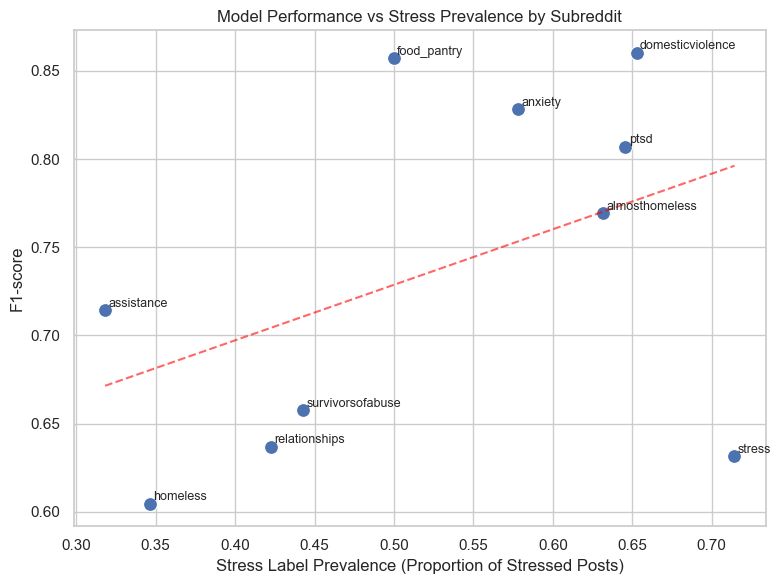

In [25]:
# Plot scatterplot to visualise relationship between F1-score and stress prevalence
plt.figure(figsize=(8,6))

# Scatter points
sns.scatterplot(
    data=subreddit_analysis,
    x="stress_rate",
    y="F1",
    s=100
)

# Line of best fit
sns.regplot(
    data=subreddit_analysis,
    x="stress_rate",
    y="F1",
    scatter=False,
    ci=None,
    line_kws={
        "color": "red",
        # dotted / dashed line
        "linestyle": "--",   
        "linewidth": 1.5,    
        "alpha": 0.6        
    }
)

# Annotate subreddit names
for idx in subreddit_analysis.index:
    plt.text(
        subreddit_analysis.loc[idx, "stress_rate"] + 0.002,
        subreddit_analysis.loc[idx, "F1"] + 0.002,
        idx,
        fontsize=9
    )

plt.xlabel("Stress Label Prevalence (Proportion of Stressed Posts)")
plt.ylabel("F1-score")
plt.title("Model Performance vs Stress Prevalence by Subreddit")
plt.tight_layout()
plt.show()

The positively sloped regression line indicates that subreddits with higher stress prevalence tend to achieve higher F1-scores. For example, communities such as domesticviolence, ptsd, and anxiety exhibit both high proportions of stressed posts and strong classification performance. This suggests that in these trauma- or mental-health-focused communities, stress is expressed more explicitly through clear emotional and self-referential language, making detection easier for a lexical model.

In contrast, subreddits such as homeless and relationships show lower stress prevalence alongside lower F1-scores. These communities often involve broader life discussions where stress may be expressed indirectly, embedded within narratives, or mixed with neutral or positive language. Such implicit and context-dependent expressions are harder for TF-IDF representations to capture, leading to reduced performance.

However, stress prevalence alone does not fully explain model effectiveness. The stress subreddit presents a notable counterexample: despite having a very high proportion of stressed posts, its F1-score is only moderate. This suggests that even in explicitly stress-oriented communities, the ways individuals articulate distress can be highly varied and nuanced. Diverse coping narratives, reflective language, or mixed emotional tones may reduce the consistency of lexical patterns, making classification more challenging.

## 5.3 Error Analysis

### 5.3.1 Counts for each error type and correct cases

In [26]:
# Identify error types
test_df["error_type"] = "correct"
test_df.loc[(test_df["label"] == 0) & (test_df["pred_label"] == 1), "error_type"] = "false_positive"
test_df.loc[(test_df["label"] == 1) & (test_df["pred_label"] == 0), "error_type"] = "false_negative"

# Count errors
print(test_df["error_type"].value_counts())


error_type
correct           518
false_positive    133
false_negative     64
Name: count, dtype: int64


### 5.3.2 Examine Most Confident Wrong Predictions

In [27]:
# False positives
fp = test_df[test_df["error_type"] == "false_positive"].sort_values("pred_prob", ascending=False)

# False negatives
fn = test_df[test_df["error_type"] == "false_negative"].sort_values("pred_prob", ascending=True)

# Columns to display
error_cols = ["subreddit", "pred_prob", "confidence", "clean_text"]

# Consolidate false positives 
fp_table = (
    fp[error_cols]
    .rename(columns={
        "subreddit": "Subreddit",
        "pred_prob": "Predicted Probability (Stress)",
        "confidence": "Annotator Confidence",
        "clean_text": "Post Text"
    })
)

# Consolidate false negatives 
fn_table = (
    fn[error_cols]
    .rename(columns={
        "subreddit": "Subreddit",
        "pred_prob": "Predicted Probability (Stress)",
        "confidence": "Annotator Confidence",
        "clean_text": "Post Text"
    })
)

# Round numeric columns for readability
for tbl in [fp_table, fn_table]:
    tbl["Predicted Probability (Stress)"] = tbl["Predicted Probability (Stress)"].round(3)
    tbl["Annotator Confidence"] = tbl["Annotator Confidence"].round(3)

print("Top False Positives:")
display(fp_table.head(10))

print("\nTop False Negatives:")
display(fn_table.head(10))

Top False Positives:


,Subreddit,Predicted Probability (Stress),Annotator Confidence,Post Text
50,relationships,0.844,0.6,"none of the issues we discuss get addressed. 6) after a while, i get really pissed, my significant other gets angry with me over some issue, and she ends up breaking up with me. i am weary of this whole emotional drama that i have to go through to end a relationship. i almost feel like it's not even my choice to end a relationship. is there a way to avoid this whole process?"
241,ptsd,0.841,1.0,"i feel like i am just being written off because of my diagnosis before anyone even tries to look into it and see if anything else might be at play. i'd just as soon not say anything about my ptsd to be taken seriously, but it appears in my medical records. or when i list my medications as required, drs usually ask me what the meds are treating and it comes up then. has anyone else had this experience? what has worked for you to be taken seriously?"
60,survivorsofabuse,0.830,0.0,"i was younger than 13 during my period of abuse and one thing i'm noticing now is that i can't wrap my head around consent. people tell me that i couldn't possibly consent to anything that happened, even if i asked for it. that i didn't even know what was happening to me. it doesn't feel that way to me. on paper, i get that."
633,survivorsofabuse,0.824,0.8,"but it took me months afterward to end it. i remember him screaming at me, calling me stupid, calling me a moody bitch when i got frustrated at him for screaming and insulting me, threatening to break up with me, holding his “love” for me over my head when i wasn’t doing things his way, getting drunk and high and cheating on me and then coercing me into helping him fake a piss test, and on and on and on.... and the whole time i knew he was being an abusive asshole and i *still stayed. * i had absolutely no reason not to leave him, and it was 100% in my power to end things between us. but i didn’t."
425,relationships,0.823,0.6,"the few gal friends i associate with are either in relationships or kind of just brush me off or fake like they want to hang out but really don’t when the time comes. my school has no clubs whatsoever, so i can’t really meet anybody that way. i do go to a fairly small school though, around 7,000 students. i always wanted to be in that group that always hangs out. so i honestly don’t know what to do or how to go about this situation."
604,anxiety,0.817,1.0,"my flaws seemed huge to me, and i assumed everyone thought negatively of me all the time. my life was consumed by a spiral of negative thoughts and social anxiety. i went to my doc, admitted my social anxiety, and he prescribed me lexapro 10mg/day. i took my first pill a few days ago, and not two hours later, i had nearly complete relief of my anxiety of all kinds. the bad thoughts completely stopped."
401,ptsd,0.806,0.8,"now i’m in a healthy relationship. this man is the love of my life. he always pushes for me to be better and i resist it sometimes. i’ve turned on him fearing him having a dark objective, and i don’t understand all my triggers. all i know is sometimes i see my incredibly loving boyfriend as my incredibly abusive ex and it breaks my heart because he’s the only person that tends to me so well... he does everything he can to help me always he saved me from that awful relationship... he saved my life."
269,ptsd,0.806,0.6,he pretty much told me that he was angry and disappointed and would probably not forgive me for a while and that i owe him. i was going to go... i still want to. i just am looking at either going to this wedding and being evicted or not going and dealing with the disappointment. i don't feel like i have a choice.
167,relationships,0.793,0.6,"how do i handle this without looking petty or selfish? ** **edit: i'm getting a lot of replies telling me that i just need to stop letting her push me around. i know that, and the whole idea behind posting here was to get some advice on how to do just that. i truly a


Top False Negatives:


,Subreddit,Predicted Probability (Stress),Annotator Confidence,Post Text
175,relationships,0.101,0.600,"we met about 2.5 years ago, both somewhat fresh off our respective divorces. i felt we had a real connection, we fell for each other hard, dated (eventually lived together) for a little less than a year before she got pregnant. we were both really happy as we had both talked about wanting children - at the time we got pregnant we were ""not not trying,"" we had definitely had many conversations and were both on board and happy to have a child together. we felt we had met our true love in each other. things have been rough since the birth of our son."
174,relationships,0.190,0.667,"he is our little angel and we are both gaga for him, but money has been extraordinary tight, adjusting to parent life and sleep deprivation has been tough for both of us. we were fighting and bickering a bit for the first time in his first months of life, but i figured that was normal for new parents. i work in the financial industry for a modest income (working hard currently to get to the next level where i'll make substantially more) and she works for an arts-based nonprofit. i have no particular attachment to the financial industry, it's just been a way to pay the bills and i find it interesting enough. she's a passionate artist though, always knew she wanted to be one, and it's really important to her."
615,survivorsofabuse,0.241,0.600,"i'd like to note that i have had a couple close individuals look at my emails, evidence, etc since the last court date. i'm not that crazy, but i showed them the emails because i wanted to make sure they were real. the emails, evidence, and notes are all real. i checked my phone history, and the phone calls to the advocate and office are all logged and sufficient in length to indicate that an actual conversation occurred. i never doubted reality before the abuse, and i have never done so outside of the abuse."
507,stress,0.248,0.667,"we had 2 classes together, so we spent a few hours together most days working through problem sets. this next semester, i won't even have that. i'll probably be in more isolation this time around. any tips are appreciated. thanks!"
516,almosthomeless,0.252,0.571,"she ended up relapsing on drugs and said that she hasn't had any feelings for me in months. she stopped taking her bipolar medications about a week before and was absolutely manic. ended up she had not only relapsed but was cheating on me with a dealer, an ex, and was looking for couples on some hookup site(all things she's claimed on facebook) even though we were having sex at least daily. then near the end of her manic state she decided she was moving to colorado at the drop of a dime and left. this leaves me in georgia staying at her mothers house without a vehicle."
680,relationships,0.273,0.000,"so i met this girl last year, in november. although we only dated officially for around a month, the feelings became very intense. around the week before christmas, she confessed she had been cheating on me with someone. at the time she was very distant towards me, and of course the cheating explained that. she and i met up last week to talk, i thought i would get closure but all i felt afterwards was a deep sense of regret."
566,ptsd,0.284,0.571,"i would like to reach out for help from someone supportive before an episode becomes too intense to ask for help. i would like to acknowledge the symptoms and temporary nature of the situation as to let it pass without causing additional damage. i finally realized that fighting my traumatic episodes is like a rigid oak tree trying to resist a flooding dam. do any of you guys have ways to be ""okay"" with an episode? if so, how do you find the flexibility and patience to not fight against it?"
66,assistance,0.293,0.800,"last week while my girlfriend was out of the country i noticed our puppy luca wasn't acting himself. i took him to the emergency clinic and after some tests they told 

To better understand the model’s limitations beyond quantitative metrics, we examine some interesting false positive and false negative cases. These examples reveal how linguistic nuance, narrative structure, and implicit emotional expression affect model performance.

---

### False Negative Example 1  
> “We met about 2.5 years ago… we were both really happy… Things have been rough since the birth of our son.”

This post describes a shift from past happiness to present relational strain. However, the text contains many strong positive lexical cues such as “happy”, “real connection”, and “true love”. A TF-IDF based model treats these tokens independently and assigns them strong non-stress weights. Although the distress is implied later (“things have been rough”), it is not expressed with explicit stress-related keywords.  

This suggests that the model struggles with narrative temporal shifts, where positive past experiences dominate the lexical representation even though the current situation is stressful. Bag-of-words representations do not encode discourse progression over time, causing positive historical language to dilute present distress signals.

---

### False Negative Example 2  
> “Next semester I won't even have that. I'll probably be in more isolation this time… Any tips are appreciated. Thanks!”

Here, distress is expressed implicitly through anticipated isolation and uncertainty about the future. However, the language remains polite and measured (“Any tips are appreciated. Thanks!”), lacking explicit emotional vocabulary such as “anxious” or “overwhelmed”.  

This highlights that many individuals express stress indirectly through contextual cues (e.g. social isolation or future uncertainty) rather than overt emotional terms. TF-IDF models rely heavily on explicit lexical markers of distress, and therefore struggle when stress is conveyed through subtle or polite phrasing. This demonstrates the difficulty of detecting implicit, context-dependent stress expressions.

---

### False Positive Example 1  
> “my life was consumed by a spiral of negative thoughts and social anxiety… after medication… I had nearly complete relief…”

Although the overall narrative describes recovery, the post contains several strong distress-related lexical tokens such as “spiral of negative thoughts” and “social anxiety”. TF-IDF assigns high weights to these negative expressions, while failing to capture the later narrative shift towards relief and improvement. Again, this error reflects a limitation in modelling narrative polarity shifts, where posts move from distress to recovery within the same text.

---

### False Positive Example 2  
> “almost decided to live in my car… heavily suicidal for a week… but I decided I can't live like this anymore… you need to begin to change.”

This post describes severe past distress but ends with a hopeful and determined outlook. The model predicts “stressed” due to the strong presence of highly weighted distress-related terms such as “suicidal” and “losing my mind”. However, the ground truth label may reflect a human interpretation that the individual is now coping or improving.  

This indicates that human annotations incorporate overall narrative trajectory and recovery framing, while TF-IDF responds primarily to the presence and frequency of distress-related lexical cues. Consequently, the model may overpredict stress in reflective recovery narratives where distress is discussed retrospectively.

### 5.3.3 Distribution of Annotator Confidence by Error Type

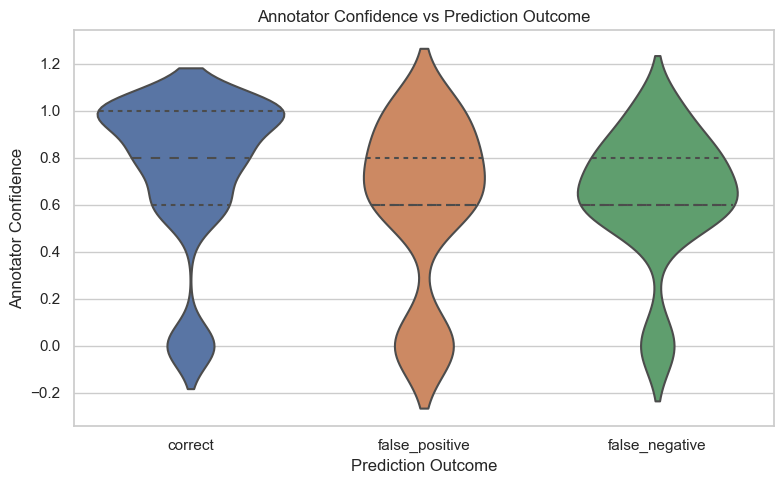

In [28]:
# Violin plot to compare confidence across correct and incorrect predictions
plt.figure(figsize=(8,5))
sns.violinplot(
    data=test_df,
    x="error_type",
    y="confidence",
    order=["correct", "false_positive", "false_negative"],
    inner="quartile"
)
plt.xlabel("Prediction Outcome")
plt.ylabel("Annotator Confidence")
plt.title("Annotator Confidence vs Prediction Outcome")
plt.tight_layout()
plt.show()

In [29]:
# Summary statistics for annotator confidence stratified by error type
conf_summary = (
    test_df.groupby("error_type")["confidence"]
    .agg(["mean", "median", "std", "count"])
    .loc[["correct", "false_positive", "false_negative"]]
)
display(conf_summary)

,mean,median,std,count
error_type,,,,
correct,0.755562,0.8,0.317464,518
false_positive,0.607769,0.6,0.352071,133
false_negative,0.641890,0.6,0.268779,64


We analyse annotator confidence across correct predictions, false positives, and false negatives to assess whether misclassifications are associated with label ambiguity. The results show that posts which the model misclassifies tend to have lower annotator confidence on average compared to correctly classified posts. This suggests that many errors occur on inherently ambiguous instances that are challenging even for human annotators to label with high certainty. Such posts likely contain subtle, indirect, or context-dependent expressions of stress, making them difficult to distinguish reliably based on lexical cues alone.

Overall, the lower confidence associated with misclassified posts suggests that a portion of the model’s errors reflects genuine ambiguity in the data rather than purely model limitations.

# 6 Final Model - TF-IDF + Logistic Regression with Text and Engineered Features

## 6.1 Select Features and Build Feature Matrices

In [30]:
from sklearn.preprocessing import StandardScaler

train_df["text_length"] = train_df["clean_text"].astype(str).str.len()
test_df["text_length"] = test_df["clean_text"].astype(str).str.len()

# Define columns to exclude
exclude_cols = [
    "subreddit", "post_id", "sentence_range", "text", "id",
    "label", "clean_text", "confidence", "social_timestamp"
]

# Select auxiliary computed features
aux_cols = [
    col for col in train_df.columns
    if col not in exclude_cols and train_df[col].dtype != "object"
]

print(f"Number of auxiliary features: {len(aux_cols)}")

# Extract matrices
X_train_aux = train_df[aux_cols]
X_test_aux = test_df[aux_cols]

# Scale computed features
scaler = StandardScaler()
X_train_aux_scaled = scaler.fit_transform(X_train_aux)
X_test_aux_scaled = scaler.transform(X_test_aux)


Number of auxiliary features: 109


## 6.2 Recreate TF-IDF Using Best Parameters

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

best_params = grid_search.best_params_

tfidf = TfidfVectorizer(
    ngram_range=best_params["tfidf__ngram_range"],
    min_df=best_params["tfidf__min_df"],
    max_df=best_params["tfidf__max_df"],
    sublinear_tf=best_params["tfidf__sublinear_tf"],
    stop_words=best_params["tfidf__stop_words"]
)

# Fit on training text and transform both train and test sets
X_train_tfidf = tfidf.fit_transform(train_df["clean_text"])
X_test_tfidf = tfidf.transform(test_df["clean_text"])

## 6.3 Combine Text + Engineered Features

In [32]:
# Concatenate TF-IDF text features with scaled auxiliary features into a single feature matrix
from scipy.sparse import hstack

X_train_combined = hstack([X_train_tfidf, X_train_aux_scaled])
X_test_combined = hstack([X_test_tfidf, X_test_aux_scaled])

# Verify final dimensionality after combining feature sets
print("Combined feature shape:", X_train_combined.shape)

Combined feature shape: (2838, 110205)


## 6.4 Train Combined Logistic Regression Model

In [33]:
# Train logistic regression on the combined text and auxiliary feature matrix
combined_model = LogisticRegression(
    C=best_params["clf__C"],
    class_weight=best_params["clf__class_weight"],
    solver=best_params["clf__solver"],
    penalty=best_params["clf__penalty"],
    max_iter=3000,
    random_state=42
)

combined_model.fit(X_train_combined, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,3
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,3000
,multi_class,'deprecated'


We move to the final modelling stage, where we test whether psychological and linguistic engineered features add value beyond raw text. While the baseline model relied solely on lexical signals captured by TF-IDF, this extended model incorporates auxiliary features such as LIWC-based lexical indicators, sentiment scores, readability measures, social engagement metrics, and text length.

All auxiliary computed features are standardised to ensure they are on comparable scales for logistic regression. The TF-IDF representation is then recreated using the best hyperparameters identified during grid search, ensuring a controlled and fair comparison with the baseline model. The text and engineered features are combined via sparse concatenation, allowing the classifier to jointly learn from both linguistic content and feature representations.

A logistic regression model with the same tuned hyperparameters as the baseline is trained on this combined feature space. This consistent setup isolates the effect of adding engineered features, enabling a direct evaluation of whether they provide incremental predictive value beyond language alone.

## 6.5 Combined Model Results on Held-out Test Set

In [34]:
y_pred_combined = combined_model.predict(X_test_combined)

print("Combined Model Test F1-score:", f1_score(y_test, y_pred_combined))
print("\nClassification Report (Combined Model):")
print(classification_report(y_test, y_pred_combined, target_names=["Not Stressed", "Stressed"]))


Combined Model Test F1-score: 0.7742782152230971

Classification Report (Combined Model):
              precision    recall  f1-score   support

Not Stressed       0.77      0.72      0.74       346
    Stressed       0.75      0.80      0.77       369

    accuracy                           0.76       715
   macro avg       0.76      0.76      0.76       715
weighted avg       0.76      0.76      0.76       715



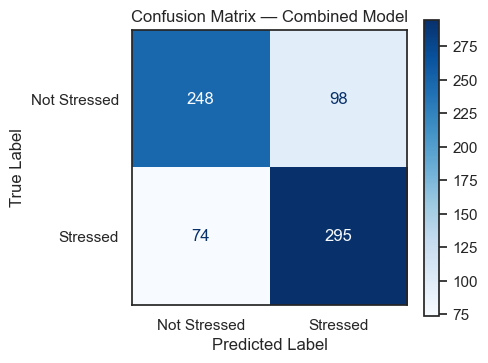

In [35]:
# Plot confusion matrix to evaluate classification performance of the combined model
cm_combined = confusion_matrix(y_test, y_pred_combined, labels=[0, 1])

with sns.axes_style("white"):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_combined,
        display_labels=["Not Stressed", "Stressed"]
    )
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)

    ax.set_title("Confusion Matrix — Combined Model")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    plt.tight_layout()
    plt.show()

The combined model, which integrates TF-IDF text features with engineered psychological and behavioural features, achieves an F1-score of approximately 0.774 on the held-out test set. This represents a modest improvement over the text-only baseline, indicating that auxiliary features provide some incremental predictive value beyond raw lexical signals.

The classification report shows a more balanced precision–recall trade-off across classes. In particular, recall for the “Stressed” class remains high, suggesting that the model continues to effectively identify stressed posts while slightly improving overall precision. The confusion matrix further illustrates this behaviour: compared to the baseline, the combined model reduces false positives while maintaining a strong number of true positives, indicating more conservative and targeted stress predictions.

Overall, these results suggest that psychological and linguistic engineered features complement lexical cues by providing additional contextual signals.

## 6.6 Performance Comparison with Baseline Model

In [36]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# Confusion matrices
cm_base = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_comb = confusion_matrix(y_test, y_pred_combined, labels=[0, 1])

# Unpack: [[TN, FP], [FN, TP]]
tn_b, fp_b, fn_b, tp_b = cm_base.ravel()
tn_c, fp_c, fn_c, tp_c = cm_comb.ravel()

# Type I error = FP / (FP + TN)
type1_b = fp_b / (fp_b + tn_b)
type1_c = fp_c / (fp_c + tn_c)

# Type II error = FN / (FN + TP)
type2_b = fn_b / (fn_b + tp_b)
type2_c = fn_c / (fn_c + tp_c)

# Consolidate metrics into a dataframe
comparison = pd.DataFrame({
    "Model": ["Text Only", "Text + Auxiliary"],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_combined)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_combined)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_combined)
    ],
    "False Positives": [fp_b, fp_c],
    "False Negatives": [fn_b, fn_c],
    "True Positives": [tp_b, tp_c],
    "True Negatives": [tn_b, tn_c],
    "Type I Error Rate (FPR)": [type1_b, type1_c],
    "Type II Error Rate (FNR)": [type2_b, type2_c]
})

comparison

,Model,F1,Precision,Recall,False Positives,False Negatives,True Positives,True Negatives,Type I Error Rate (FPR),Type II Error Rate (FNR)
0,Text Only,0.755886,0.696347,0.826558,133,64,305,213,0.384393,0.173442
1,Text + Auxiliary,0.774278,0.750636,0.799458,98,74,295,248,0.283237,0.200542


To assess incremental value, we compare the combined model directly against the text-only baseline using identical evaluation metrics. The combined model improves overall F1-score and precision, while slightly reducing recall relative to the baseline. This indicates that the extended model is more selective in predicting stress, trading off some sensitivity for improved precision.

From an error perspective, the combined model substantially reduces false positives, lowering the Type I error rate (false alarm rate). However, this comes with a slight increase in false negatives, reflected in a higher Type II error rate (miss rate).

Taken together, the comparison shows that engineered features provide complementary information that improves overall discriminative performance, but they also shift the model towards greater precision and slightly lower sensitivity. This nuanced trade-off is important when considering real-world deployment where the relative costs of false positives and false negatives must be carefully balanced, and will be further discussed in Section 7.

## 6.7 Feature Importance of Engineered Psychological Features in the Combined Model

In [37]:
from IPython.display import HTML, display

# Auxiliary Feature Importance Table
combined_coefs = combined_model.coef_[0]
n_text_features = X_train_tfidf.shape[1]
aux_coefs = combined_coefs[n_text_features:]

aux_importance = pd.DataFrame({
    "feature": aux_cols,
    "coefficient": aux_coefs
})
aux_importance["abs_coefficient"] = aux_importance["coefficient"].abs()
aux_importance = aux_importance.sort_values("abs_coefficient", ascending=False)

# Scrollable full table
scroll_html = aux_importance.to_html(index=False)

display(HTML(f"""
<div style="max-height: 450px; overflow-y: auto; border: 1px solid #ddd;">
{scroll_html}
</div>
"""))

# Directional tables
top_positive = aux_importance.sort_values("coefficient", ascending=False).head(15)
top_negative = aux_importance.sort_values("coefficient", ascending=True).head(15)

print("Top Positive Predictors of Stress:")
display(top_positive[["feature", "coefficient"]])

print("\nTop Negative Predictors of Not-Stress:")
display(top_negative[["feature", "coefficient"]])

feature,coefficient,abs_coefficient
lex_liwc_function,1.033962,1.033962
lex_liwc_negemo,-0.893040,0.893040
lex_liwc_affect,0.871813,0.871813
text_length,0.648607,0.648607
lex_liwc_auxverb,-0.578829,0.578829
lex_liwc_Clout,-0.577031,0.577031
lex_liwc_feel,0.552133,0.552133
lex_liwc_WC,-0.521505,0.521505
lex_liwc_percept,-0.478928,0.478928
lex_liwc_article,-0.461475,0.461475


Top Positive Predictors of Stress:


,feature,coefficient
10,lex_liwc_function,1.033962
31,lex_liwc_affect,0.871813
108,text_length,0.648607
52,lex_liwc_feel,0.552133
92,lex_liwc_Apostro,0.344509
88,lex_liwc_QMark,0.340216
7,lex_liwc_WPS,0.280719
9,lex_liwc_Dic,0.275805
63,lex_liwc_risk,0.268087
65,lex_liwc_focuspresent,0.254562



Top Negative Predictors of Not-Stress:


,feature,coefficient
33,lex_liwc_negemo,-0.893040
21,lex_liwc_auxverb,-0.578829
4,lex_liwc_Clout,-0.577031
2,lex_liwc_WC,-0.521505
49,lex_liwc_percept,-0.478928
19,lex_liwc_article,-0.461475
32,lex_liwc_posemo,-0.459857
6,lex_liwc_Tone,-0.456438
11,lex_liwc_pronoun,-0.433311
48,lex_liwc_differ,-0.417032


To interpret the contribution of engineered features, we examine the logistic regression coefficients corresponding only to the engineered psychological, linguistic, and behavioural variables. Coefficients are sorted by absolute magnitude to identify which engineered signals exert the strongest influence on predictions, while separate tables for the top positive and negative coefficients show the directional impact of the strongest signals.

The results show that several LIWC-derived features, such as overall linguistic function usage, affective language, and first-person pronouns, are among the strongest positive predictors of stress. Text length also appears as a notable positive signal, suggesting that longer, more elaborative posts are more likely to be associated with stress expression. These patterns align with what was discovered in earlier EDA analyses.

Conversely, features such as negative emotion balance, clout, perceptual processes, and general linguistic markers (e.g. articles, pronouns, and tone) emerge as negative predictors, indicating associations with more neutral or structured discourse typical of non-stressed posts. Sentiment polarity also appears as a negative predictor, reinforcing the intuition that more positive overall sentiment reduces the likelihood of a stress classification.

It is important to note that lexical TF-IDF features constitute the primary signal for stress detection, as evidenced by the strong baseline performance and high recall of the text-only model. The engineered psychological and behavioural features therefore act as complementary signals that improve the robustness of the final combined model rather than replacements for lexical cues. Their main contribution appears to be in refining predictions and reducing false positives, suggesting that emotional tone, complexity, and discourse style help the model make more conservative and context-aware stress classifications.

# 

# 7 Clinical Ethics & Deployment Considerations

While the model demonstrates promising ability to detect stress signals in social media text, its deployment in real-world mental health contexts raises important ethical and practical considerations.

## Risks of Misclassification

A key concern lies in the consequences of incorrect predictions, particularly when viewed through Type I and Type II error rates.

### Type II Errors (False Negatives — Missed Distress)

The Type II error rate reflects the proportion of genuinely stressed posts that are incorrectly classified as non-stressed. In a mental health context, this “miss rate” is especially critical and should be kept as low as possible. Missing a truly distressed individual could delay recognition of psychological struggles and reduce opportunities for timely support or intervention.

From the model comparison, the combined model exhibits a higher false negative rate than the text-only baseline, indicating that more genuinely stressed posts were overlooked. This trade-off is ethically significant: while reducing false alarms is useful, failing to identify actual distress can have more severe consequences. In sensitive domains like mental health, false negatives are often considered more harmful than false positives because they risk leaving vulnerable individuals unnoticed.

### Type I Errors (False Positives — Over-Identification)

Type I errors occur when non-stressed posts are incorrectly flagged as stressed. While these errors may seem less harmful than false negatives, excessive false positives can undermine the credibility of the system and dilute attention given to genuinely distressed cases. If benign posts are frequently flagged, practitioners or moderators may become desensitised to alerts, reducing the likelihood that true high-risk signals are prioritised appropriately. Over time, this erosion of trust can weaken the system’s effectiveness in identifying and supporting individuals who actually require intervention.

## Interpretability and Transparency

The use of logistic regression with interpretable textual and psychological features supports transparent decision-making. Stakeholders can inspect influential words and engineered signals (e.g. LIWC categories, sentiment, syntax complexity), which helps ensure accountability when predictions are used in sensitive mental health contexts.

## Appropriate Scope of Deployment

Given the ethical implications of both Type I and Type II errors, the model should not be used for automated diagnosis or individual-level clinical judgement. Linguistic signals alone cannot fully capture a person’s psychological state, and misclassification risks remain substantial.

A more appropriate application would be population-level monitoring of anonymised online discourse to identify aggregate stress trends across communities. Such usage focuses on public health insights rather than making determinations about specific individuals.

## Human-in-the-Loop Safeguards

To mitigate the risks associated with misclassification, any deployment should incorporate a human-in-the-loop framework. Automated predictions should function as preliminary screening signals, with trained professionals reviewing flagged content and contextual information before any conclusions or interventions are made.

## Summary

In summary, while the model demonstrates that stress can be detected from linguistic and psychological cues, ethical deployment requires caution. In particular, the Type II error rate is of paramount concern in mental health applications, as overlooking truly stressed individuals can have serious consequences. Therefore, the system should be used as a supportive analytical tool with strong transparency and human oversight, rather than as a standalone decision-making system.


# 8 Final Conclusion

Overall, the results demonstrate that stress is meaningfully detectable through language. The text-only TF–IDF + Logistic Regression model already achieved strong performance (Test F1 ≈ 0.756), indicating that lexical cues such as expressions of anxiety, rumination, and negative self-referential language are highly informative.

The per-subreddit analysis further revealed that model performance varies across communities. Subreddits where users explicitly discuss personal struggles (e.g. anxiety, domesticviolence, ptsd) showed higher F1-scores, while more conversational or implicitly expressive communities (e.g. relationships, homeless) were harder to classify. This supports the EDA insight that explicit narrative-style posts contain clearer linguistic markers of distress, whereas implicit or socially moderated expressions of stress are more ambiguous.

Error analysis provided deeper insights into model limitations. False negatives often occurred in posts that maintained polite or hopeful tones despite underlying distress, suggesting that purely lexical models struggle when stress is expressed indirectly or through moderated language. Conversely, false positives frequently involved recounting past distress using strongly negative words, which the TF–IDF representation could not temporally contextualise. These findings highlight a key limitation of sparse bag-of-words models: they capture word frequency but not nuanced semantic relationships such as temporal framing or stories about emotional recovery.

Introducing engineered psychological and behavioural features (LIWC, sentiment, readability, and social engagement metrics) produced a modest improvement in overall F1-score (≈ 0.774). The combined model reduced false positives substantially, suggesting that auxiliary features helped differentiate between general negative language and genuine psychological distress. However, the increase in false negatives indicates a trade-off: while auxiliary signals improve precision, they may slightly reduce sensitivity to subtle stress expressions.

In a real-world mental health context, ethical considerations are a top priority. False negatives are particularly concerning, as failing to identify genuinely distressed individuals could delay support or intervention. False positives, while less immediately harmful, may still lead to inefficient resource allocation, privacy concerns, and reduced trust in automated systems. Therefore, such models should not be used for individual diagnosis or automated surveillance. Instead, they are more appropriately deployed for population-level trend monitoring, early risk screening with human oversight, or as decision-support tools that assist rather than replace mental health professionals.

In conclusion, this project shows that:
1. Stress is linguistically detectable through lexical and emotional cues in online discourse.
2. Model performance is higher in communities where distress is expressed explicitly.
3. Errors primarily arise when stress is implicit, temporally framed, or socially moderated.
4. Engineered psychological and behavioural features provide additional context beyond language alone.
5. Ethical deployment requires transparency, cautious interpretation, and human-in-the-loop oversight.

To conclude, the findings demonstrate both the promise and limitations of AI-driven stress detection, highlighting the need to balance predictive performance with interpretability, contextual nuance, and responsible clinical use.